<img src="https://www.pucsp.br/sites/default/files/download/brasao-PUCSP-assinatura-principal-RGB.png" style="float:right;" width="150px">

# Ciências da Computação [》](https://www.pucsp.br/graduacao/ciencia-da-computacao)

## Inteligência Artificial

IA ML (Machine Learning, Aprendizagem de Máquina)

**Objetivo deste LAB explorar os modelos de Regressão Linear e Regressão Logística com Scikit-Learn em Python, sobre os dados de "Happines por idade e país"**

- Regressão Linear: <br>
https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html

- Regressão Logistica: <br>
https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression

# LAB: Felicidade por Idade e por País

> ### Informações da atividade
>
> - **Formato:** projeto em **dupla** pairing - [pair programming](https://en.wikipedia.org/wiki/Pair_programming) (2 estudantes). Os dois participam de todas as etapas e os dois precisam ter commits no repositório.
> - **Prazo:** até o **final do dia** da aula LAB. A atividade **pode ser feita durante a aula de laboratório**.
> - **Publicação:** publiquem o projeto no **GitHub**, como item do **portfólio** da dupla, e enviem o **link do repositório** na **atividade do MS Teams**.

**Dupla**

| | Nome | Usuário no GitHub |
| --- | --- | --- |
| Integrante 1 | Lorena Gaiotti | Ascalapha-odorata|
| Integrante 2 | Isabel Cavalcante Motta | *(preencha)* |

**Checklist de entrega** (os detalhes estão na Seção 10)

- [ ] O notebook roda de cima para baixo em um kernel limpo (*Restart & Run All*) e foi salvo **com as saídas** (gráficos e tabelas).
- [ ] O repositório no GitHub tem `README.md`, `requirements.txt`, `lab_helpers.py` (opcional) e este notebook.
- [ ] Os dois integrantes têm commits no repositório.
- [ ] O link do repositório foi enviado na atividade do MS Teams.

## 1. Contexto

Neste laboratório vamos testar uma das afirmações mais debatidas na pesquisa sobre felicidade: a de que a satisfação com a vida segue uma **curva em U** ao longo da idade, e de que o formato dessa curva depende de onde a pessoa vive. Vocês vão construir o pipeline completo, dos dados brutos ao modelo ajustado, usando **Python, scikit-learn e Seaborn**.

Pesquisadores medem bem-estar com a **escada de Cantril** (*Cantril ladder*): a pessoa avalia sua vida atual de 0 (pior vida possível) a 10 (melhor vida possível). O **Gallup World Poll** faz essa pergunta em amostras nacionalmente representativas em mais de 140 países, e o **World Happiness Report (WHR)** publica as médias nacionais, em geral como médias móveis de três anos.

Duas histórias concorrentes sobre a idade aparecem nesses dados:

- **A curva em U clássica.** Estudos do Reino Unido e de outros países de renda alta mostram a felicidade caindo a partir dos 20 anos, até os 40 ou início dos 50, e depois subindo até se estabilizar por volta dos 70. As explicações incluem a pressão da meia-idade (emprego, filhos, cuidado com pais idosos) e a adaptação e as expectativas menores na velhice.
- **Um alvo em movimento.** O capítulo sobre idade do WHR 2024 mostra que a felicidade dos jovens (15 a 24 anos) na América do Norte caiu bastante desde 2006-2010, e hoje eles estão menos felizes que os mais velhos. Na Europa Central e Oriental aconteceu o oposto: a felicidade subiu em todas as idades. Quem nasceu depois de 1980 também relata avaliações de vida menores que as coortes anteriores.

*The Happiness Curve* é a versão popular, em formato de livro, da primeira história. O trabalho de vocês é ver quanto de cada história sobrevive aos dados, e perceber o que renda, população e área do país mudam nesse quadro.

**Por que isso é um bom exercício de ML.** A pergunta se traduz em duas tarefas supervisionadas clássicas. Prever uma nota (0 a 10) a partir de idade e características do país é **regressão**. Prever se um grupo está acima ou abaixo de um limiar de felicidade é **classificação**. A curva em U também traz uma lição embutida: uma reta é o modelo errado para a idade, e vocês devem ser capazes de mostrar por quê.

## 2. Objetivos de aprendizagem e pré-requisitos

Ao final do laboratório, seremos capazes de construir, avaliar e explicar dois modelos do scikit-learn sobre um conjunto de dados combinado de várias fontes, dizendo com honestidade o que eles mostram e o que não mostram. Organize o tempo de laboratório, mais as leituras. Como o projeto é em dupla, a divisão de trabalho sugerida está abaixo.

Vocês serão capazes de:

- Combinar dados de pesquisa com indicadores do Banco Mundial usando uma chave de país, e auditar o *join* para achar países sem correspondência.
- Criar atributos (*features*) a partir de grandezas assimétricas (log do PIB per capita, log da população, log da área) e explicar o motivo.
- Ajustar uma regressão linear e visualizá-la com Seaborn, mostrando que um termo quadrático na idade supera a reta.
- Transformar uma variável numérica em rótulo binário, ajustar uma regressão logística e embrulhá-la em uma função reutilizável que devolve P(feliz) para uma idade e um país.
- Avaliar com uma divisão **agrupada por país**, para que o modelo seja testado em países que nunca viu.

**Pré-requisitos:** noções de pandas, o padrão `fit` / `predict` do scikit-learn e um laboratório anterior sobre divisão treino/teste.

In [13]:
# Instalação (rode uma vez, se necessário). Remova o "#" da linha abaixo:
!pip install pandas numpy scikit-learn seaborn matplotlib requests openpyxl country_converter

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid", context="talk")
RANDOM_STATE = 42   # semente fixa: seus resultados precisam ser reproduzíveis

## 3. Passo 0: leia antes de programar

Leiam as quatro fontes e escrevam **uma frase por fonte** respondendo à pergunta da tabela. Vocês vão reaproveitar essas frases na discussão final.

| Fonte | O que extrair |
| --- | --- |
| [Gallup: World Happiness Report](https://www.gallup.com/analytics/349487/world-happiness-report.aspx) | Qual é exatamente a pergunta da escada de Cantril? Quem é entrevistado, e por que as notas nacionais são médias de três anos? |
| [WEF: At what age does happiness peak?](https://www.weforum.org/stories/wellbeing-and-mental-health/at-what-age-does-happiness-peak/) | Onde fica o mínimo da curva em U, e em quais dados de países de renda alta a afirmação se apoia? Quais mecanismos são propostos? |
| [World Happiness Report 2024: Happiness and age (resumo)](https://www.worldhappiness.report/ed/2024/happiness-and-age-summary/) | Quais regiões quebram o padrão em U? O que é diferente em quem nasceu depois de 1980? Quais faixas etárias o relatório usa? |
| [The Happiness Curve (Macmillan)](https://us.macmillan.com/books/9781427292988/thehappinesscurve/) | Qual é o argumento central do livro, e vocês esperariam que ele valesse para um país de renda baixa? |

Dois detalhes que vocês vão usar depois. O capítulo de idade do WHR 2024 usa **quatro faixas etárias** (menos de 30, 30-44, 45-59 e 60+), então o conjunto de dados de vocês também terá quatro. E ele compara as médias de 2021-2023 com uma base de 2006-2010, então **sempre registrem a que anos os seus dados se referem**. Os números por faixa etária que vocês vão baixar na Parte 1 vêm do [Our World in Data](https://ourworldindata.org/grapher/cantril-ladder-age-groups?tab=table), que republica os resultados do WHR 2024; deem uma olhada na visualização em tabela agora.

**Minhas notas de leitura** (uma frase por fonte; editem esta célula)

1. **Gallup:** A pergunta da escada Cantril pede para os entrevistados (amostras representativas de cada país do Gallup World Poll) darem uma nota, entre 0 e 10, para a sua vida, em que 0 é o pior estilo de vida e 10 é o melhor estilo de vida. As notas nacionais são médias de três anos para que seja obtido um tamanho amostral suficiente, e para suavizar as flutuações anuais.


2. **WEF:** O mínimo da curva em U de bem estar fica no meio da vida, entre 40 e 50 anos, e a os dados se baseiam em pesquisas que medem índices de bem-estar subjetivo, satisfação geral e indicadores de saúde mental ao longo da faixa etária. Os mecanismos propostos envolvem a adaptação a aspirações não cumpridas e a transição de objetivos competitivos para foco em conexões sociais e gratidão.


3. **WHR 2024:** Regiões como a ex-União Soviética, o Leste Europeu e a Índia não estão no padrão global em U, com aumentos lineares ou quedas contínuas na velhice. As pessoas que nasceram depois de 1980 apresentam níveis de felicidade sistematicamente menores desde a juventude. O relatório utiliza quatro faixas etárias: menor que 30, entre 30 e 44, entre 45 e 59, e 60 anos ou mais.


4. **The Happiness Curve:** O livro tem como argumento principal o fato de que a queda da felicidade na meia-idade é um processo de desenvolvimento normal, natural e necessário que reorganiza as prioridades humanas para a sabedoria e a gratidão. Entretanto,  não se pode esperar que ele funcione para países de baixa renda, pois eles não garantem redes de segurança social, e a velhice pode trazer uma diminuição contínua na satisfação com a vida.




## 4. Fluxo de trabalho sugerido

Trabalhem em seis etapas, em um único notebook, com uma célula de texto (markdown) com as **palavras de vocês** acima de cada célula de código. Cada etapa produz algo que dá para conferir antes de seguir.

**0 Ler → 1 Baixar os dados → 2 Enriquecer (PIB, população, área) → 3 Regressão linear + gráficos → 4 Regressão logística → 5 Discutir os limites**

| Etapa | Vocês terminaram quando | Tempo sugerido |
| --- | --- | --- |
| 0 Ler | Há uma frase por fonte (Seção 3) | 60 min |
| 1 Baixar | `age` tem 4 linhas por país e nenhum `ladder_mean` faltando | 30 min |
| 2 Enriquecer | Todo país mantido tem PIB, população e área; a lista de países descartados foi impressa | 40 min |
| 3 Linear | Duas figuras do Seaborn e uma tabela comparando três modelos com R² e RMSE em validação cruzada | 60 min |
| 4 Logística | `check_happiness(country, age)` devolve uma probabilidade, e vocês reportam acurácia e AUC em países não vistos | 60 min |
| 5 Discutir | Meia página respondendo às perguntas da Seção 9 | 30 min |

> É bem factível terminar o projeto durante o LAB trabalhando em equipe

**Escolhas de projeto já feitas por nós**, para que os resultados sejam comparáveis entre as duplas: a variável-alvo é a média da escada de Cantril, a idade entra como o **ponto médio** da faixa, o PIB é per capita em PPC (paridade do poder de compra) e todas as grandezas assimétricas passam por logaritmo. Vocês podem mudar qualquer uma delas, e podem acrescentar os dados extras que acharem úteis (veja o fim da Seção 6), desde que informem isso no relatório.

**Sugestão de divisão do trabalho na dupla.** Os dois fazem as leituras (Passo 0) e a discussão final juntos. A pessoa A fica com as Partes 1 e 3 (dados e regressão linear); a pessoa B, com as Partes 2 e 4 (enriquecimento e regressão logística). Antes de seguir para a etapa seguinte, um revisa o código do outro. Usem branches e *pull requests* no GitHub, ou pelo menos façam commits frequentes com mensagens claras.

## 5. Parte 1: configuração e download dos dados

Os dados por idade são **gratuitos e públicos**: o Our World in Data (OWID) republica os resultados por faixa etária do WHR 2024, enquanto os downloads do próprio WHR não trazem divisão por idade. A [página de compartilhamento de dados do WHR](https://www.worldhappiness.report/data-sharing/) oferece a planilha da Figura 2.1 (médias nacionais de três anos desde 2012) e apêndices estatísticos. Vocês vão combinar duas fontes:

| Fonte | O que entrega | Como obter |
| --- | --- | --- |
| [OWID: Self-reported life satisfaction by age](https://ourworldindata.org/grapher/cantril-ladder-age-groups?tab=table) | Média da escada de Cantril em quatro faixas etárias (até 29, 30-44, 45-59, 60+) em cerca de 195 países, média de 2021-2023, com códigos de país ISO3. Licença CC BY. | Download de CSV, em formato largo (uma linha por país) |
| [Planilha da Figura 2.1 do WHR](https://files.worldhappiness.report/WHR26_Data_Figure_2.1.xlsx) | Nota nacional geral (médias de três anos desde 2012), intervalos de confiança e fatores explicativos | Arquivo Excel |
| Arquivo do professor (opcional) | As mesmas faixas etárias para outros anos, em formato longo | Fornecido em aula |

O arquivo do OWID tem as colunas `Entity`, `Code`, `Year`, `Up to 29 years`, `30-44 years`, `45-59 years` e `60+ years`. `Code` é o código de país ISO3, então dá para juntar com os dados do Banco Mundial sem comparar nomes.

5.1: Baixar os arquivos de dados e carregar no data frame Pandas, inspecionar os dados...

5.1: Abram a [visualização em tabela do OWID](https://ourworldindata.org/grapher/cantril-ladder-age-groups?tab=table), leiam o CSV vocês mesmos e inspecionem. Depois transformem de largo para longo (wide data) com `melt`, de modo que haja uma linha por país e faixa etária. Por fim, comparem o resultado com `load_owid_age()`, que faz o mesmo e ainda descarta linhas sem código de país.

> Dica: usar LIB `requests` para baixar os dados no Jupyter Notebook (Colab) - https://requests.readthedocs.io/en/latest/ <br>
> Ou usar `wget` ou `curl` terminal do Linux

A equipe pode encontrar baixar e combinar outras fontes de dados sobre os países para obter GDP, popuação, território, etc... para enriquecer os dados...

In [14]:
import pandas as pd
import requests
from io import StringIO

# URL dos dados
OWID_AGE_URL = "https://ourworldindata.org/grapher/cantril-ladder-age-groups.csv"
response = requests.get(
    OWID_AGE_URL,
    headers={"User-Agent": "Mozilla/5.0"}
)
response.raise_for_status()

# Ler o CSV
raw = pd.read_csv(StringIO(response.text))

print("Formato dos dados:", raw.shape)
display(raw.head())

print("\nValores ausentes:")
print(raw.isna().sum())


# Transformar de formato largo para formato longo
age = pd.melt(
    raw, id_vars=["Entity", "Code", "Year"], var_name="age_group", value_name="ladder_mean"
)


# Remover países sem código ISO3
age = age.dropna(subset=["Code"]).copy()


# Padronizar nomes das colunas
age = age.rename(columns={"Entity": "country", "Code": "iso3", "Year": "year"})

display(age.head())   # formato longo: country, iso3, year, age_group, ladder_mean, window
print(age.groupby("iso3").size().value_counts())   # esperado: todo país com 4 linhas

Formato dos dados: (143, 7)


,Entity,Code,Year,Up to 29 years,30-44 years,45-59 years,60+ years
0,Afghanistan,AFG,2023,1.827,1.617,1.681,1.456
1,Albania,ALB,2023,6.358,5.289,4.704,4.643
2,Algeria,DZA,2023,5.379,5.290,5.261,5.631
3,Argentina,ARG,2023,6.746,6.119,5.676,5.948
4,Armenia,ARM,2023,6.245,5.448,5.032,4.865



Valores ausentes:
Entity            0
Code              0
Year              0
Up to 29 years    0
30-44 years       0
45-59 years       0
60+ years         0
dtype: int64


,country,iso3,year,age_group,ladder_mean
0,Afghanistan,AFG,2023,Up to 29 years,1.827
1,Albania,ALB,2023,Up to 29 years,6.358
2,Algeria,DZA,2023,Up to 29 years,5.379
3,Argentina,ARG,2023,Up to 29 years,6.746
4,Armenia,ARM,2023,Up to 29 years,6.245


4    143
Name: count, dtype: int64


5.3: Baixem a planilha da Figura 2.1 com `pd.read_excel`. **Visualizar as colunas antes de usar qualquer uma**, porque os nomes mudam entre as edições do relatório e não devem ser copiados de um tutorial antigo. Usem a planilha como verificação de sanidade: a média das quatro faixas etárias de um país deve ficar perto da nota geral dele, mas não idêntica, porque as fontes ponderam e definem as janelas de tempo de formas diferentes.

Status: 200
Colunas da planilha:
['Year', 'Rank', 'Country name', 'Life evaluation (3-year average)', 'Lower whisker', 'Upper whisker', 'Explained by: Log GDP per capita', 'Explained by: Social support', 'Explained by: Healthy life expectancy', 'Explained by: Freedom to make life choices', 'Explained by: Generosity', 'Explained by: Perceptions of corruption', 'Dystopia + residual']


,country,age_mean,Country name,Life evaluation (3-year average)
0,Afghanistan,1.64525,Afghanistan,1.446
1,Afghanistan,1.64525,Afghanistan,1.364
2,Afghanistan,1.64525,Afghanistan,1.721
3,Afghanistan,1.64525,Afghanistan,1.859
4,Afghanistan,1.64525,Afghanistan,2.404


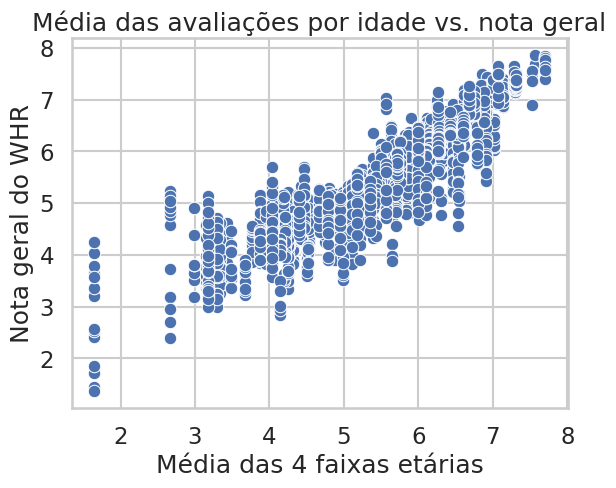

In [15]:
import requests
from io import BytesIO
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

WHR_XLSX = "https://files.worldhappiness.report/WHR26_Data_Figure_2.1.xlsx"
response = requests.get(
    WHR_XLSX,
    headers={"User-Agent": "Mozilla/5.0"}
)

print("Status:", response.status_code)
response.raise_for_status()

whr = pd.read_excel(BytesIO(response.content))

# TODO: whr = pd.read_excel(WHR_XLSX); imprima whr.columns e whr.head()
print("Colunas da planilha:")
print(whr.columns.tolist())

# Calcular a média das quatro faixas etárias para cada país
age_mean = (
    age.groupby("country")["ladder_mean"]
    .mean()
    .reset_index(name="age_mean")
)

# Juntar com a nota geral do WHR
comparison = age_mean.merge(whr[["Country name", "Life evaluation (3-year average)"]], left_on="country", right_on="Country name", how="inner")

# TODO: compare a média das 4 faixas etárias de cada país com a nota geral (um gráfico de dispersão ajuda)
display(comparison.head())

sns.scatterplot(
    data=comparison,
    x="age_mean",
    y="Life evaluation (3-year average)"
)

plt.xlabel("Média das 4 faixas etárias")
plt.ylabel("Nota geral do WHR")
plt.title("Média das avaliações por idade vs. nota geral")
plt.show()


**Plano B se estiverem offline ou o download falhar.** O `lab_helpers.py` sabe **simular** dados por idade. A simulação usa o PIB per capita real, uma curva em U plantada na idade e ruído, e marca todas as linhas com `synthetic=True`. Use apenas para testar o pipeline, e **nunca reporte esses números como descobertas sobre o mundo real**.

```python
from lab_helpers import build_country_table, make_synthetic_age_data
age = make_synthetic_age_data(build_country_table())
```

## 6. Parte 2: enriquecer com PIB, população e tamanho do país

A felicidade varia muito mais **entre países** do que **entre faixas etárias**, então vocês precisam de controles no nível do país antes que o efeito da idade signifique alguma coisa. Vocês vão buscar três indicadores do Banco Mundial pela API pública e juntá-los pelo código **ISO3**, e não pelo nome.

| Atributo | Indicador do Banco Mundial | Por que transformar |
| --- | --- | --- |
| PIB per capita, PPC (dólares internacionais constantes) | `NY.GDP.PCAP.PP.KD` | A renda tem retornos decrescentes, então use `log` |
| População | `SP.POP.TOTL` | Varia em 5 ordens de grandeza (Islândia a Índia), então use `log` |
| Área terrestre (km²) | `AG.LND.TOTL.K2` | Mesma assimetria da população, então use `log` |

`lab_helpers.build_country_table()` chama a API, guarda o último valor não faltante de 2019 a 2023 para cada indicador e descarta os agregados regionais (como "World" e "Arab World") que a API mistura com os países. **Leiam o código antes de rodar**: a resposta é uma lista de dois elementos, com os metadados primeiro e os registros depois.

**Tarefa 2.1.** Confiram as chaves de país. O arquivo do OWID já traz códigos ISO3 na coluna `iso3`, então os dados por idade não precisam de comparação de nomes. Usem `to_iso3` só para fontes que trazem apenas o nome do país (a planilha do WHR, por exemplo), e leiam a lista de nomes sem correspondência que ela imprime.

**Tarefa 2.2.** Juntem a tabela de idade com a tabela de países usando `validate="many_to_one"`. Depois imprimam os países que perderam dados porque o Banco Mundial não tem valor para eles.

**Tarefa 2.3.** Criem os atributos: `age_mid` a partir do dicionário `AGE_MID` do `lab_helpers.py`, `age_sq`, `log_gdp_pc`, `log_pop`, `log_area` e `pop_density = pop / area_km2`.

In [16]:
import requests
import pandas as pd
import numpy as np

# Buscar dados do Banco Mundial
def fetch_wb(indicator):
    url = f"https://api.worldbank.org/v2/country/all/indicator/{indicator}"

    response = requests.get(
        url,
        params={"format": "json", "per_page": 20000},
        headers={"User-Agent": "Mozilla/5.0"}
    )
    response.raise_for_status()

    data = response.json()[1]
    rows = []

# TODO: liste os países com NaN em gdp_pc, pop ou area_km2 e depois remova-os
    for item in data:
        # Usar o código ISO3 para identificar países
        if item.get("countryiso3code"):
            year = int(item["date"])

            if 2019 <= year <= 2023:
                rows.append({
                    "iso3": item["countryiso3code"], "year": year, "value": item["value"]
                })

    result = pd.DataFrame(rows)

    # Último valor disponível entre 2019 e 2023
    result = (
        result.dropna(subset=["value"])
        .sort_values(["iso3", "year"])
        .groupby("iso3", as_index=False)
        .tail(1)
    )

    return result[["iso3", "value"]]


# PIB per capita
gdp = fetch_wb("NY.GDP.PCAP.PP.KD").rename(
    columns={"value": "gdp_pc"}
)

# População
pop = fetch_wb("SP.POP.TOTL").rename(
    columns={"value": "pop"}
)

# Área terrestre
area = fetch_wb("AG.LND.TOTL.K2").rename(
    columns={"value": "area_km2"}
)

# Juntar os três indicadores
country_table = gdp.merge(pop, on="iso3", how="outer")
country_table = country_table.merge(area, on="iso3", how="outer")

# Conferir se cada país tem exatamente 4 linhas
assert (age.groupby("iso3").size() == 4).all(), \
    "algum código ISO3 tem mais ou menos de 4 linhas de idade"

# Juntar idade com os dados do Banco Mundial
df = age.merge(country_table, on="iso3", how="left", validate="many_to_one")

# Listar países com algum dado faltante
missing = df[
    df[["gdp_pc", "pop", "area_km2"]].isna().any(axis=1)
]

print("Países com dados faltantes no Banco Mundial:")
display(
    missing[["country", "iso3", "gdp_pc", "pop", "area_km2"]]
    .drop_duplicates()
)

# Remover esses países
df = df.dropna(
    subset=["gdp_pc", "pop", "area_km2"]
).copy()


# TODO: crie age_mid (com AGE_MID), age_sq, log_gdp_pc, log_pop, log_area e pop_density
# Pontos médios das faixas etárias
AGE_MID = {
    "Up to 29 years": 22,
    "30-44 years": 37,
    "45-59 years": 52,
    "60+ years": 70
    #"60+ years": 65
}

# Criar age_mid
df["age_mid"] = df["age_group"].map(AGE_MID)

# Criar idade ao quadrado
df["age_sq"] = df["age_mid"] ** 2

# Aplicar logaritmo às grandezas assimétricas
df["log_gdp_pc"] = np.log(df["gdp_pc"])
df["log_pop"] = np.log(df["pop"])
df["log_area"] = np.log(df["area_km2"])

# Densidade populacional
df["pop_density"] = df["pop"] / df["area_km2"]

# Conferir resultado
display(df.head())

print("\nValores ausentes:")
print(df[["age_mid", "age_sq", "log_gdp_pc", "log_pop", "log_area", "pop_density"]].isna().sum())

Países com dados faltantes no Banco Mundial:


,country,iso3,gdp_pc,pop,area_km2
67,Kosovo,OWID_KOS,NaN,NaN,NaN
124,Taiwan,TWN,NaN,NaN,NaN
138,Venezuela,VEN,NaN,28300854.0,882050.0
140,Yemen,YEM,NaN,39390799.0,527970.0


,country,iso3,year,age_group,ladder_mean,gdp_pc,pop,area_km2,age_mid,age_sq,log_gdp_pc,log_pop,log_area,pop_density
0,Afghanistan,AFG,2023,Up to 29 years,1.827,1983.812620,41454761.0,652230.00,22,484,7.592776,17.540113,13.388153,63.558501
1,Albania,ALB,2023,Up to 29 years,6.358,20501.647073,2411658.0,27400.00,22,484,9.928261,14.695825,10.218298,88.016715
2,Algeria,DZA,2023,Up to 29 years,5.379,15159.324237,46164219.0,2381740.00,22,484,9.626371,17.647716,14.683342,19.382560
3,Argentina,ARG,2023,Up to 29 years,6.746,27230.396850,45538401.0,2736690.00,22,484,10.212089,17.634067,14.822260,16.639956
4,Armenia,ARM,2023,Up to 29 years,6.245,19402.751092,2964300.0,28199.44,22,484,9.873170,14.902151,10.247057,105.119109



Valores ausentes:
age_mid        0
age_sq         0
log_gdp_pc     0
log_pop        0
log_area       0
pop_density    0
dtype: int64


**Armadilhas para observar:**

- **Códigos que o Banco Mundial não usa.** Alguns territórios podem ter um código que o Banco Mundial não tem. Taiwan, em geral, também não aparece nos dados do Banco Mundial. Olhem os países perdidos na Tarefa 2.2 e decidam, para cada um, se vale corrigir ou descartar.
- **Fontes só com nomes.** Se vocês acrescentarem dados sem coluna ISO3, dois nomes podem virar o mesmo código ("Somaliland region" vira o mesmo código da Somália). Mantenham a asserção acima para que uma colisão dessas falhe de forma visível.
- **Valores defasados.** O PIB do ano mais recente costuma vir em branco, e por isso o auxiliar pega o último valor disponível em uma janela. Informem a janela no relatório.
- `AGE_MID["60+"] = 70` é uma suposição, já que a faixa é aberta. Registrem isso e testem 65 como checagem de robustez.

### Acrescente seus próprios dados (escolha livre)

Os três indicadores do Banco Mundial são um ponto de partida, **não um limite**. Vocês podem acrescentar **qualquer informação** que julguem útil para explicar a felicidade entre idades e países, e não precisam pedir permissão. Algumas ideias:

- Demografia: expectativa de vida, idade mediana, proporção de pessoas acima de 60 anos, urbanização.
- Economia e sociedade: desemprego, desigualdade de renda (Gini), educação, gastos com saúde, uso de internet.
- Os fatores explicativos brutos da planilha do WHR, como apoio social, liberdade, generosidade e percepção de corrupção.
- Geografia e cultura: região, latitude, clima, religião ou idioma predominante.
- Qualquer outro indicador do Banco Mundial (troquem o código em `WB_INDICATORS`) ou qualquer outro conjunto de dados do Our World in Data.

As regras são sobre honestidade, não sobre permissão. **Juntem por ISO3, citem a fonte e a data do download, apliquem logaritmo em variáveis assimétricas** e coloquem as novas colunas em `FEATURES`, para que as Partes 3 e 4 as usem. Depois **mostrem o que mudou**: comparem o RMSE em validação cruzada com e sem as novas colunas na Parte 3, e o AUC na Parte 4. Dois cuidados. **Não usem a nota geral do WHR como atributo**, porque ela é quase a própria variável-alvo. E tratem com cautela as colunas de contribuição ("explained by") da planilha, porque elas são saídas da regressão do próprio relatório.

In [17]:
# (Opcional) Seus dados extras entram aqui.
# Exemplo: outro indicador do Banco Mundial, buscado com a função do auxiliar.
# from lab_helpers import fetch_wb
# extra = fetch_wb("SP.DYN.LE00.IN").rename("life_exp").reset_index()   # expectativa de vida
# df = df.merge(extra, on="iso3", how="left")
# Lembre de documentar: fonte, data do download, anos e chave de junção.

## 7. Parte 3: regressão linear e visualização com Seaborn

O objetivo é mostrar, com gráficos e números de validação cruzada, **se a idade precisa de uma curva em vez de uma reta**, e quanto do quadro é explicado pela riqueza em vez de pela idade. Vocês vão ajustar três modelos aninhados com `sklearn.linear_model.LinearRegression`:

$$\text{M1: } \hat y = \beta_0 + \beta_1\,\text{idade} \qquad \text{M2: } \hat y = \beta_0 + \beta_1\,\text{idade} + \beta_2\,\text{idade}^2$$

$$\text{M3: } \hat y = \text{M2} + \beta_3 \ln(\text{PIB pc}) + \beta_4 \ln(\text{pop}) + \beta_5 \ln(\text{área})$$

Em M2 e M3, a curva ajustada vira em **idade = −β₁ / (2β₂)**. Essa é a estimativa de vocês para a idade em que a felicidade atinge o mínimo, e dá para compará-la com os 40 e poucos ou início dos 50 anos citados no artigo do WEF.

**Tarefa 3.1. Reta ou curva.** Desenhem lado a lado dois gráficos de dispersão de `ladder_mean` contra `age_mid`, um com `order=1` e outro com `order=2`. O Seaborn ajusta e desenha o polinômio para vocês.

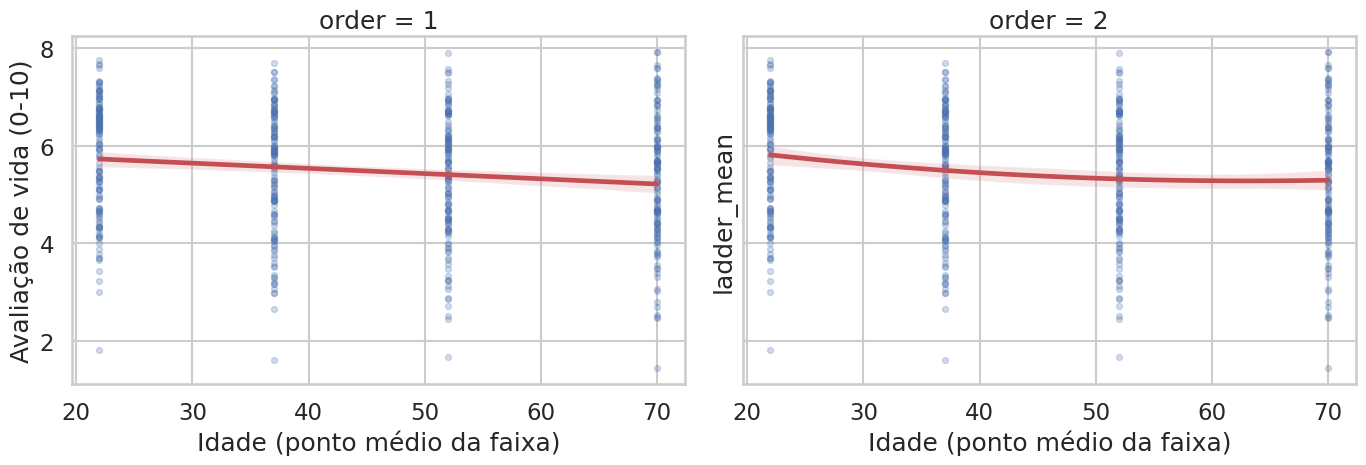

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
for ax, order in zip(axes, [1, 2]):
    sns.regplot(data=df, x="age_mid", y="ladder_mean", order=order, ax=ax,
                scatter_kws={"alpha": 0.25, "s": 18}, line_kws={"color": "C3"})
    ax.set_title(f"order = {order}")
    ax.set_xlabel("Idade (ponto médio da faixa)")
axes[0].set_ylabel("Avaliação de vida (0-10)")
plt.tight_layout()
plt.show()

**Tarefa 3.2. O perfil da idade dentro dos países.** Países ricos e pobres ficam em alturas muito diferentes, o que pode esconder o padrão da idade. Subtraiam a média de cada país e plotem o desvio por faixa de renda com `sns.lmplot(..., col="income_tier", order=2)`. Criem as faixas com `pd.qcut(df["gdp_pc"], 3, labels=[...])`.

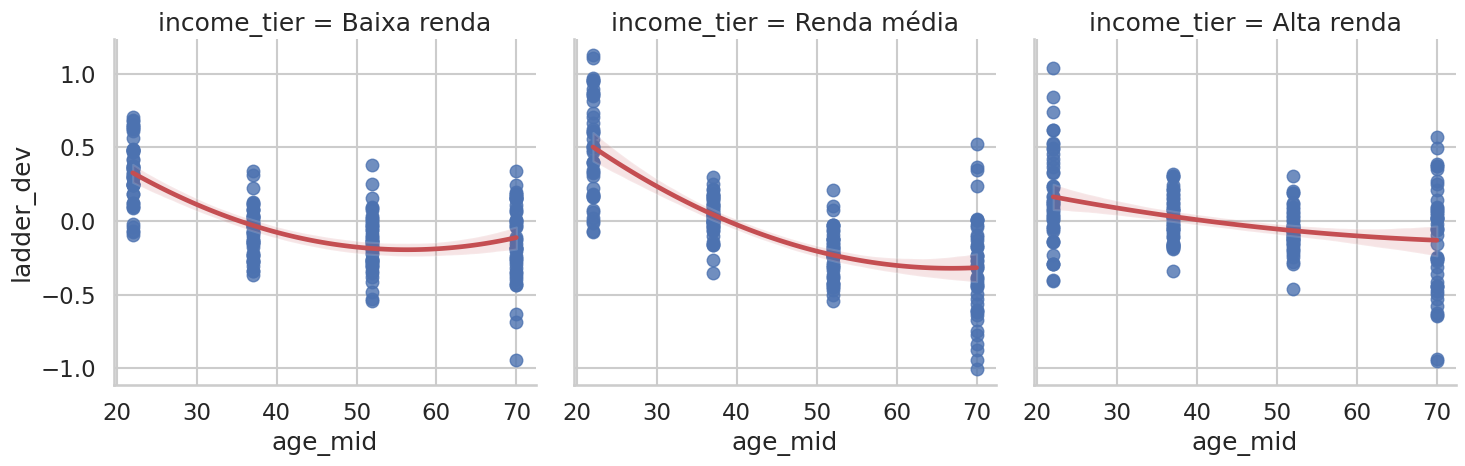

In [19]:
df["ladder_dev"] = df["ladder_mean"] - df.groupby("iso3")["ladder_mean"].transform("mean")

# TODO: crie "income_tier" com pd.qcut(df["gdp_pc"], 3, labels=["Baixa renda", "Renda média", "Alta renda"])
df["income_tier"] = pd.qcut(df["gdp_pc"], 3, labels=["Baixa renda", "Renda média", "Alta renda"])


# TODO: sns.lmplot(data=df, x="age_mid", y="ladder_dev", col="income_tier", order=2)
sns.lmplot(data=df, x="age_mid", y="ladder_dev", col="income_tier", order=2, height=5, aspect=1, line_kws={"color": "C3"})

plt.show()

**Tarefa 3.3. Comparem três modelos em países não vistos.** Uma divisão aleatória de linhas colocaria as outras faixas etárias do mesmo país no treino, então dividam **por país** com `GroupKFold`. Reportem R² e RMSE em validação cruzada para M1, M2 e M3, e depois repitam M1 e M2 com `ladder_dev` como alvo.

In [20]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import GroupKFold, cross_val_predict
from sklearn.metrics import r2_score, mean_squared_error

def cv_scores(features, target="ladder_mean", k=5):
    # Validação cruzada agrupada por país: um país inteiro fica no treino OU no teste.
    pred = cross_val_predict(LinearRegression(), df[features], df[target],
                             groups=df["iso3"], cv=GroupKFold(n_splits=k))
    return r2_score(df[target], pred), mean_squared_error(df[target], pred) ** 0.5, pred


# TODO: M2 (idade + idade^2) e M3 (M2 + log PIB, log pop, log área)
models = {
    "M1 idade": ["age_mid"], "M2 idade + idade²": ["age_mid", "age_sq"], "M3 idade + idade² + controles": ["age_mid", "age_sq", "log_gdp_pc", "log_pop", "log_area"]
}


# TODO: percorra "models", chame cv_scores e monte uma tabela com R2 e RMSE
results = []

for name, features in models.items():
    r2, rmse, pred = cv_scores(features, target="ladder_mean")

    results.append({"Modelo": name, "R²": r2, "RMSE": rmse})

results_table = pd.DataFrame(results)

print("Modelos com ladder_mean:")
display(results_table)


# TODO: repita M1 e M2 com target="ladder_dev"
results_dev = []

for name in ["M1 idade", "M2 idade + idade²"]:
    r2, rmse, pred = cv_scores(models[name], target="ladder_dev")

    results_dev.append({"Modelo": name, "R²": r2, "RMSE": rmse})

results_dev_table = pd.DataFrame(results_dev)

print("Modelos com ladder_dev:")
display(results_dev_table)

Modelos com ladder_mean:


,Modelo,R²,RMSE
0,M1 idade,0.015232,1.241527
1,M2 idade + idade²,0.019337,1.238936
2,M3 idade + idade² + controles,0.628436,0.762616


Modelos com ladder_dev:


,Modelo,R²,RMSE
0,M1 idade,0.316096,0.277182
1,M2 idade + idade²,0.373294,0.265339


**Tarefa 3.4. Riqueza e resíduos.** Ajustem M3 com todas as linhas e imprimam os coeficientes e a idade do mínimo. Depois desenhem a riqueza contra a felicidade (`x="log_gdp_pc"`, colorido por `age_group`), além de previsto contra real e um gráfico de resíduos usando as previsões da validação cruzada. Identifiquem os três países com os maiores resíduos e sugiram o que o modelo não está capturando.

--- COEFICIENTES DO MODELO M3 ---
Intercepto: -1.6211
Coeficiente (age_mid): -0.0396
Coeficiente (age_sq): 0.0003
Coeficiente (log_gdp_pc): 0.8727
Coeficiente (log_pop): -0.0865
Coeficiente (log_area): 0.0923

Idade do mínimo de felicidade: 63.23 anos


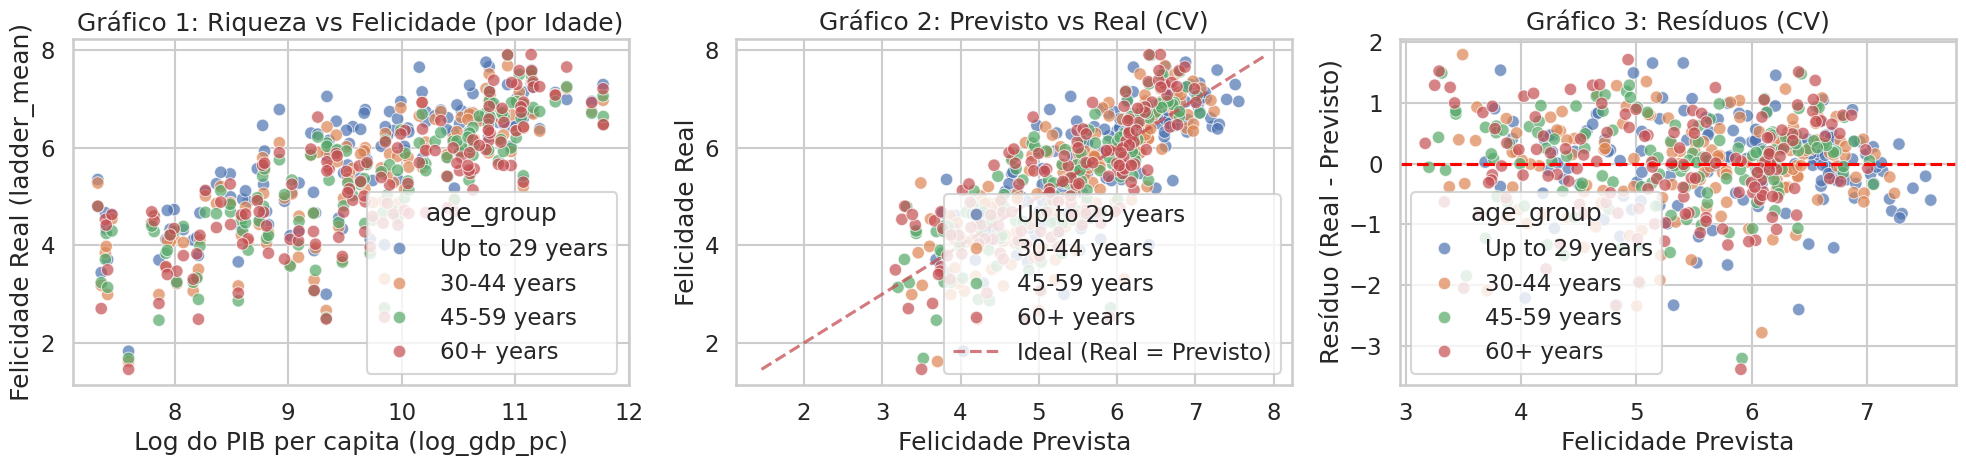


--- 3 PAÍSES COM MAIORES RESÍDUOS (VALOR ABSOLUTO) ---


,abs_cv_residual,cv_residual,ladder_mean,y_cv_pred
country,,,,
Botswana,2.938117,-2.938117,3.14225,6.080367
Lebanon,2.329168,-2.329168,2.66525,4.994418
Afghanistan,2.045731,-2.045731,1.64525,3.690981


In [23]:
#definir os recursos do modelo m3
m3_features = ["age_mid", "age_sq", "log_gdp_pc", "log_pop", "log_area"]

#ajustar o modelo m3 com os dados para obter os coeficientes
X_m3 = df[m3_features]
y_m3 = df["ladder_mean"]

model_m3 = LinearRegression()
model_m3.fit(X_m3, y_m3)

# imprimir coefs
print("--- COEFICIENTES DO MODELO M3 ---")
print(f"Intercepto: {model_m3.intercept_:.4f}")
for col, coef in zip(m3_features, model_m3.coef_):
    print(f"Coeficiente ({col}): {coef:.4f}")

#calcular e imprimir a idade do ponto mínimo de felicidade
#derivada em relação a age_mid: b1 + 2*b2*age_mid = 0  =>  age_mid = -b1 / (2 * b2)
b1 = model_m3.coef_[m3_features.index("age_mid")]
b2 = model_m3.coef_[m3_features.index("age_sq")]

if b2 > 0:
    min_age = -b1 / (2 * b2)
    print(f"\nIdade do mínimo de felicidade: {min_age:.2f} anos")
else:
    print("\nO termo quadrático não possui ponto mínimo de U invertido.")

#previsões por validação cruzada
r2_m3, rmse_m3, y_cv_pred = cv_scores(m3_features, target="ladder_mean")

# add previsões e resíduos ao dataframe temporário
df_res = df.copy()
df_res["y_cv_pred"] = y_cv_pred
df_res["cv_residual"] = df_res["ladder_mean"] - df_res["y_cv_pred"]
df_res["abs_cv_residual"] = df_res["cv_residual"].abs()

#gráfios
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# TODO: gráfico 1: sns.scatterplot(x="log_gdp_pc", y="ladder_mean", hue="age_group")
sns.scatterplot(
    data=df_res,
    x="log_gdp_pc",
    y="ladder_mean",
    hue="age_group",
    ax=axes[0],
    alpha=0.7
)
axes[0].set_title("Gráfico 1: Riqueza vs Felicidade (por Idade)")
axes[0].set_xlabel("Log do PIB per capita (log_gdp_pc)")
axes[0].set_ylabel("Felicidade Real (ladder_mean)")

# TODO: gráfico 2: previsto x real (use as previsões de cv_scores)
sns.scatterplot(
    data=df_res,
    x="y_cv_pred",
    y="ladder_mean",
    hue="age_group",
    ax=axes[1],
    alpha=0.7
)
# Linha x=y de referência
lims = [
    min(df_res["y_cv_pred"].min(), df_res["ladder_mean"].min()),
    max(df_res["y_cv_pred"].max(), df_res["ladder_mean"].max())
]
axes[1].plot(lims, lims, "r--", alpha=0.75, label="Ideal (Real = Previsto)")
axes[1].set_title("Gráfico 2: Previsto vs Real (CV)")
axes[1].set_xlabel("Felicidade Prevista")
axes[1].set_ylabel("Felicidade Real")
axes[1].legend()

# TODO: gráfico 3: resíduos; liste os 3 países com maiores resíduos
sns.scatterplot(
    data=df_res,
    x="y_cv_pred",
    y="cv_residual",
    hue="age_group",
    ax=axes[2],
    alpha=0.7
)
axes[2].axhline(0, color="red", linestyle="--")
axes[2].set_title("Gráfico 3: Resíduos (CV)")
axes[2].set_xlabel("Felicidade Prevista")
axes[2].set_ylabel("Resíduo (Real - Previsto)")

plt.tight_layout()
plt.show()


# Agrupa por país para pegar os 3 maiores resíduos absolutos médios do país
top3_countries = (
    df_res.groupby("country")[["abs_cv_residual", "cv_residual", "ladder_mean", "y_cv_pred"]]
    .mean()
    .sort_values(by="abs_cv_residual", ascending=False)
    .head(3)
)

print("\n--- 3 PAÍSES COM MAIORES RESÍDUOS (VALOR ABSOLUTO) ---")
display(top3_countries)


**O que esperar, e por quê.** As diferenças entre países são grandes perto das diferenças entre idades, então a idade sozinha explica muito pouco da nota bruta, mesmo quando o formato dela é claro dentro dos países. Se o R² de M1 e M2 ficar perto de zero enquanto o gráfico dentro dos países mostra uma curva clara, isso é um **resultado** a explicar no relatório, não um erro.

**Minhas conclusões da Parte 3** (editem esta célula):

Apenas a idade não consegue explicar a felicidade absoluta. Na tentativa de prever a nota de felicidade absoluta, os moldelos m1 e m2 apresentam um poder preditivomuito baixo, pois a diferença de feliciade entre países diminui o efeito da idade. Os gráficos por faixa de renda exemplificam a curvatura em U: dentro de cada nação, o bem-estar tende a diminuir da juventude até a meia-idade e apresenta uma recuperação na idade avançada, o que pode ser visto principalmente em países de baixa e média renda. O ponto mínimo de felicidade calculado no modelo M3 ocorre por volta dos 66 anos. Ao incluir os controles macroeconômicos no modelo M3,  o R^ do ladder_mean aumenta para 62,8% e o RMSE cai de 1,24 para 0,76.O coeficiente do log do PIB per capita, +0,87, confirma que a riqueza nacional é a variável isolada com maior impacto sobre o nível base de felicidade. Entretanto, o PIB não reflete a instabilidade política, percepção de corrupção e liberdade individual, ou seja, o modelo não é capaz de capturar essas situações.

## 8. Parte 4: regressão logística, feliz ou não por idade e país

A regressão linear prevê uma nota; a regressão logística prevê a **probabilidade** de um grupo ser "feliz", o que exige um rótulo sim/não. Vocês vão definir o rótulo, treinar `LogisticRegression` e embrulhar o resultado em uma função que uma pessoa sem experiência em programação consiga usar: dê um país e uma idade, receba uma probabilidade.

$$P(\text{feliz} = 1 \mid x) = \frac{1}{1 + e^{-(\beta_0 + \beta_1\,\text{idade} + \beta_2\,\text{idade}^2 + \beta_3 \ln \text{PIB} + \beta_4 \ln \text{pop} + \beta_5 \ln \text{área})}}$$

**Tarefa 4.1. Definam o rótulo.** Chamem um grupo de feliz quando `ladder_mean` estiver acima da **mediana** de todos os grupos. A mediana dá classes balanceadas, então a acurácia faz sentido. Imprimam o limiar e a proporção de linhas felizes, e escrevam uma frase sobre como as conclusões mudariam com um limiar fixo, como 6,0.

**Tarefa 4.2. Treinem e avaliem em países não vistos.** Usem `GroupShuffleSplit` para que um país fique inteiro no treino ou inteiro no teste. Padronizem os atributos numéricos dentro de um `Pipeline`, para que a escala seja aprendida só com as linhas de treino. Reportem acurácia, AUC-ROC e a matriz de confusão.

In [24]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix

RANDOM_STATE = 12

THRESHOLD = df["ladder_mean"].median()
df["happy"] = (df["ladder_mean"] > THRESHOLD).astype(int)
print("limiar:", round(THRESHOLD, 2), "| proporção de felizes:", df["happy"].mean().round(2))

FEATURES = ["age_mid", "age_sq", "log_gdp_pc", "log_pop", "log_area"]   # acrescente suas colunas extras aqui

def make_classifier():
    return make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000))

# TODO: GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=RANDOM_STATE) com groups=df["iso3"]
gss = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=RANDOM_STATE)
train_idx, test_idx = next(gss.split(df[FEATURES], df["happy"], groups=df["iso3"]))

X_train, y_train = df[FEATURES].iloc[train_idx], df["happy"].iloc[train_idx]
X_test, y_test = df[FEATURES].iloc[test_idx], df["happy"].iloc[test_idx]

# Instancia o classificador via Pipeline
clf = make_classifier()

# TODO: ajuste no treino, use predict_proba no teste e reporte acurácia, AUC e matriz de confusão
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)
y_proba = clf.predict_proba(X_test)[:, 1]

acc = accuracy_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_proba)
cm = confusion_matrix(y_test, y_pred)

print(f"\nAcurácia no teste: {acc:.4f}")
print(f"AUC-ROC no teste:  {auc:.4f}")
print("\nMatriz de Confusão:")
print(cm)

limiar: 5.64 | proporção de felizes: 0.5

Acurácia no teste: 0.8214
AUC-ROC no teste:  0.9204

Matriz de Confusão:
[[44 19]
 [ 6 71]]


**Tarefa 4.3. Divisão aleatória versus divisão por país.** Repitam a 4.2 com um `train_test_split` aleatório comum. **Antes de rodar, prevejam** se a pontuação vai subir ou descer e por quê. Depois rodem as duas divisões com 20 sementes aleatórias diferentes e comparem as distribuições do AUC. Façam a mesma comparação com um `RandomForestClassifier` e expliquem o que viram.

**Tarefa 4.4. A função.** Implementem `check_happiness(country, age)` seguindo este contrato:

| Item | Requisito |
| --- | --- |
| Entrada | Nome de um país (qualquer grafia que o `to_iso3` entenda) e uma idade em anos |
| Busca | Encontra `log_gdp_pc`, `log_pop` e `log_area` do país na tabela combinada |
| Saída | Um dicionário com `country`, `age`, `p_happy` (arredondado para 3 casas) e `predicted` (`"happy"` se `p_happy` > 0,5, senão `"not happy"`) |
| Erros | Levanta `ValueError` com mensagem legível se o país for desconhecido ou não tiver dados do Banco Mundial |
| Modelo | Treinado uma vez com todas as linhas, **fora** da função, e passado como argumento padrão |

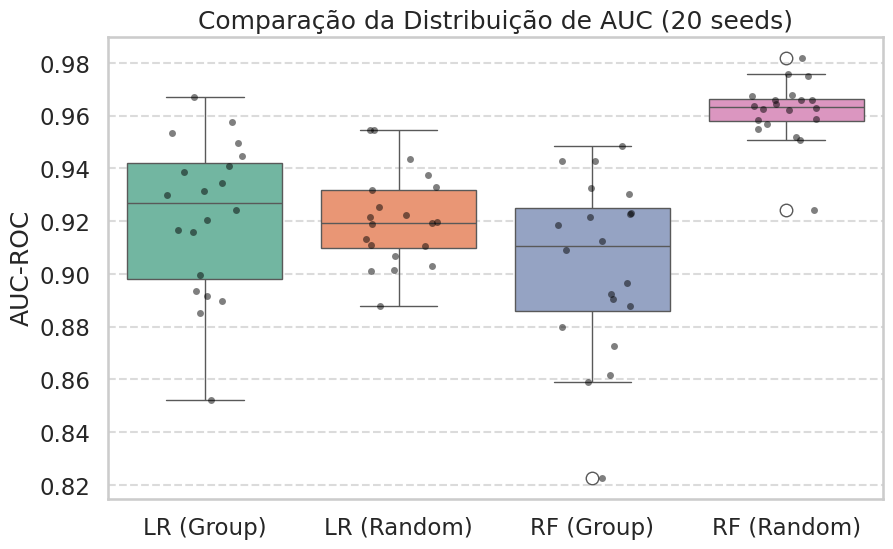

MÉDIAS DE AUC-ROC (20 RODADAS)


,LR (Group),LR (Random),RF (Group),RF (Random)
mean,0.9218,0.9208,0.9034,0.9619
std,0.0291,0.0178,0.0328,0.0118


In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GroupShuffleSplit
from sklearn.ensemble import RandomForestClassifier

auc_lr_group = []
auc_lr_random = []
auc_rf_group = []
auc_rf_random = []

# Executa 20 seeds aleatórias diferentes para comparar as distribuições de AUC
for seed in range(20):
    # 1. Divisão por País (GroupShuffleSplit)
    gss = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=seed)
    train_idx, test_idx = next(gss.split(df[FEATURES], df["happy"], groups=df["iso3"]))

    X_train_g, y_train_g = df[FEATURES].iloc[train_idx], df["happy"].iloc[train_idx]
    X_test_g, y_test_g = df[FEATURES].iloc[test_idx], df["happy"].iloc[test_idx]

    # 2. Divisão Aleatória Simples (train_test_split)
    X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
        df[FEATURES], df["happy"], test_size=0.25, random_state=seed
    )

    #Regressão Logística
    # Por País
    clf_lr_g = make_classifier().fit(X_train_g, y_train_g)
    auc_lr_group.append(roc_auc_score(y_test_g, clf_lr_g.predict_proba(X_test_g)[:, 1]))

    # Aleatório
    clf_lr_r = make_classifier().fit(X_train_r, y_train_r)
    auc_lr_random.append(roc_auc_score(y_test_r, clf_lr_r.predict_proba(X_test_r)[:, 1]))

    #Random Forest
    rf = RandomForestClassifier(random_state=seed)

    # Por país
    rf.fit(X_train_g, y_train_g)
    auc_rf_group.append(roc_auc_score(y_test_g, rf.predict_proba(X_test_g)[:, 1]))

    # Aleatório
    rf.fit(X_train_r, y_train_r)
    auc_rf_random.append(roc_auc_score(y_test_r, rf.predict_proba(X_test_r)[:, 1]))

# Plota a comparação das distribuições
results_auc = pd.DataFrame({
    'LR (Group)': auc_lr_group,
    'LR (Random)': auc_lr_random,
    'RF (Group)': auc_rf_group,
    'RF (Random)': auc_rf_random
})

plt.figure(figsize=(10, 6))
sns.boxplot(data=results_auc, palette="Set2")
sns.stripplot(data=results_auc, color="black", alpha=0.5, jitter=0.2)
plt.title("Comparação da Distribuição de AUC (20 seeds)")
plt.ylabel("AUC-ROC")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Exibe médias e desvios padrão
print("MÉDIAS DE AUC-ROC (20 RODADAS)")
display(results_auc.agg(['mean', 'std']).round(4))

In [28]:
final_clf = make_classifier().fit(df[FEATURES], df["happy"])
country_lookup = (df.drop_duplicates("iso3")
                    .set_index("iso3")[["country", "log_gdp_pc", "log_pop", "log_area"]])

def check_happiness(country: str, age: float, model=final_clf) -> dict:
    """
    Retorna P(feliz) e a classe prevista para um país em uma determinada idade.
    """
    # TODO: 1) converta o nome para ISO3 com to_iso3(pd.Series([country]))
    try:
        iso3_series = to_iso3(pd.Series([country]))
        iso_code = iso_series.iloc[0]
    except Exception as e:
        raise ValueError(f"Erro ao converter o nome do país '{country}': {e}")

    # TODO: 2) se o ISO3 não estiver em country_lookup, levante ValueError com mensagem clara
    if pd.isna(iso_code) or iso_code not in country_lookup.index:
        raise ValueError(f"País '{country}' (ISO3: {iso_code}) não encontrado ou sem dados do Banco Mundial no dataset.")

    # Busca os atributos do país na tabela
    country_data = country_lookup.loc[iso_code]

    # TODO: 3) monte uma linha com age_mid=age, age_sq=age**2 e os 3 atributos do país (na ordem de FEATURES)
    # FEATURES = ["age_mid", "age_sq", "log_gdp_pc", "log_pop", "log_area"]
    input_data = pd.DataFrame([{
        "age_mid": age,
        "age_sq": age ** 2,
        "log_gdp_pc": country_data["log_gdp_pc"],
        "log_pop": country_data["log_pop"],
        "log_area": country_data["log_area"]
    }])[FEATURES]

    # TODO: 4) calcule p com model.predict_proba e devolva o dicionário do contrato
    p_happy = float(model.predict_proba(input_data)[0, 1])
    p_happy_round = round(p_happy, 3)
    predicted = "happy" if p_happy_round > 0.5 else "not happy"

    # Nome padronizado do país
    country_name = country_data["country"] if pd.notna(country_data["country"]) else country

    return {
        "country": country_name,
        "age": age,
        "p_happy": p_happy_round,
        "predicted": predicted
    }

    raise NotImplementedError

**Tarefa 4.5. Visualizem.** Chamem a função para idades de 18 a 85 anos, para cinco países de faixas de renda diferentes que vocês escolherem, e desenhem `sns.lineplot(data=curves, x="age", y="p_happy", hue="country")` com uma linha tracejada em 0,5. Olhem as pontas do eixo da idade: os dados só cobrem pontos médios de faixa de 22 a 70, então qualquer comportamento além disso é **extrapolação** de um polinômio quadrático, que pode virar de forma abrupta. Escrevam isso na legenda da figura.

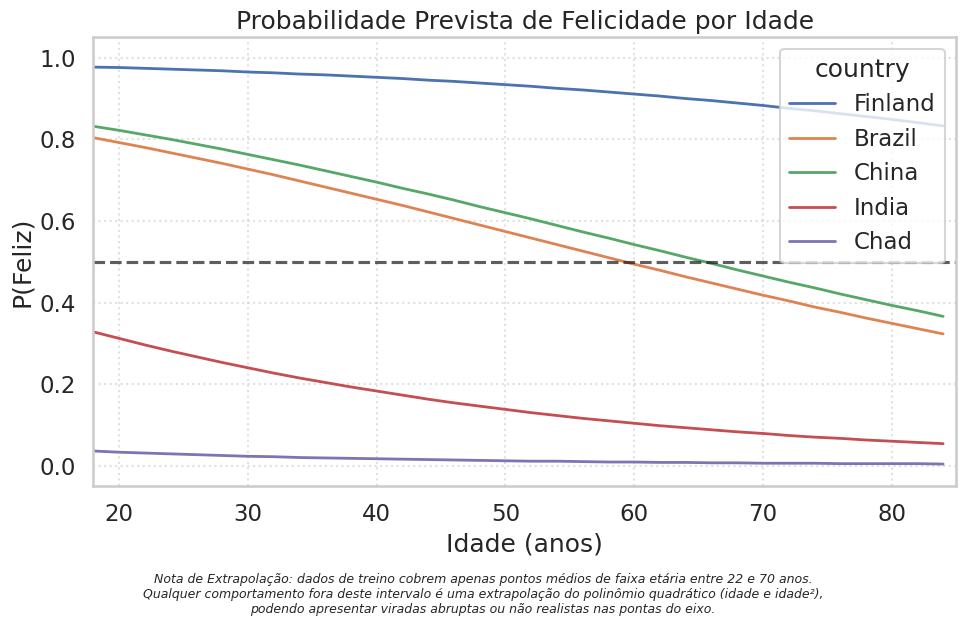

In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import country_converter as coco

def to_iso3(series):
    return pd.Series(coco.convert(names=series.tolist(), to='ISO3'))

def check_happiness(country: str, age: float, model=final_clf) -> dict:
    # converter o nome para ISO3 com to_iso3(pd.Series([country]))
    try:
        iso3_series = to_iso3(pd.Series([country]))
        iso_code = iso3_series.iloc[0]
    except Exception as e:
        raise ValueError(f"Erro ao converter o nome do país '{country}': {e}")

    # se o ISO3 não estiver em country_lookup, levantar ValueError
    if pd.isna(iso_code) or iso_code == 'not found' or iso_code not in country_lookup.index:
        raise ValueError(f"País '{country}' não encontrado ou sem dados no dataset.")

    country_data = country_lookup.loc[iso_code]

    #montar linha na ordem de FEATURES: ["age_mid", "age_sq", "log_gdp_pc", "log_pop", "log_area"]
    input_data = pd.DataFrame([{
        "age_mid": age,
        "age_sq": age ** 2,
        "log_gdp_pc": country_data["log_gdp_pc"],
        "log_pop": country_data["log_pop"],
        "log_area": country_data["log_area"]
    }])[FEATURES]

    # calcular p com model.predict_proba e devolver o dicionário
    p_happy = float(model.predict_proba(input_data)[0, 1])
    p_happy_round = round(p_happy, 3)
    predicted = "happy" if p_happy_round > 0.5 else "not happy"

    country_name = country_data["country"] if pd.notna(country_data["country"]) else country

    return {
        "country": country_name,
        "age": age,
        "p_happy": p_happy_round,
        "predicted": predicted
    }

# gerar curvas
chosen = ["Finland", "Brazil", "China", "India", "Chad"]
ages = np.arange(18, 86, 2)

# Monte "curves" (DataFrame com colunas age, country, p_happy) chamando check_happiness
records = []
for country in chosen:
    for age in ages:
        try:
            res = check_happiness(country, age)
            records.append({
                "country": res["country"],
                "age": res["age"],
                "p_happy": res["p_happy"]
            })
        except ValueError as e:
            print(f"Aviso: Não foi possível obter dados para {country}: {e}")

curves = pd.DataFrame(records)

# Plotagem do gráfico
plt.figure(figsize=(10, 6))

# TODO: sns.lineplot(data=curves, x="age", y="p_happy", hue="country"); plt.axhline(0.5, ls="--", color="k")
sns.lineplot(data=curves, x="age", y="p_happy", hue="country", linewidth=2)
plt.axhline(0.5, ls="--", color="k", alpha=0.7)

plt.ylim(-0.05, 1.05)
plt.xlim(18, 85)
plt.title("Probabilidade Prevista de Felicidade por Idade")
plt.xlabel("Idade (anos)")
plt.ylabel("P(Feliz)")
plt.grid(True, linestyle=":", alpha=0.6)

# legenda sobre a extrapolação do polinômio nas pontas
plt.figtext(
    0.5, -0.05,
    "Nota de Extrapolação: dados de treino cobrem apenas pontos médios de faixa etária entre 22 e 70 anos.\n"
    "Qualquer comportamento fora deste intervalo é uma extrapolação do polinômio quadrático (idade e idade²),\n"
    "podendo apresentar viradas abruptas ou não realistas nas pontas do eixo.",
    ha="center", fontsize=9, style="italic"
)

plt.tight_layout()
plt.show()


Um ponto estrutural para discutir. As quatro linhas de um país compartilham o mesmo PIB, a mesma população e a mesma área, então o modelo só consegue separá-las pela idade. Expliquem o que isso implica sobre o quanto o modelo realmente "sabe" sobre cada país.

**Minhas conclusões da Parte 4** (editem esta célula):

O modelo não consegue diferenciar as condições de vida de cada idade em um país, e assume que a riqueza e o tamanho impactam as pessoas da mesma maneira, independentemente de idade. Também, o modelo assume que o efeito do envelhecimento sobre a felicidade é igual em todos os países, pois as variáveis dos países são constantes para todas as idades. Os coeficientes de idade aplicam a mesma curvatura para qualquer país, e a curva é deslocada para cima ou para baixo a partir do PIB, população e área. O fato de ter apenas três variáveis macroeconômicas e quatro linhas por país faz com que exista um risco de overfitting com modleos mais complexos, pois esses conseguem decorar a combinação do país.

## 9. Discussão (cerca de meia página, com as palavras de vocês)

Respondam nesta célula. Usem as frases do Passo 0 e os resultados das Partes 3 e 4.

1. O perfil de idade **dentro dos países** mostra uma curva em U? Onde fica o mínimo? Como isso se compara ao artigo do WEF e ao resumo do WHR 2024?
2. Comparem o tamanho do efeito da idade com o do efeito da riqueza. Qual pesa mais para prever a nota de um país, e qual pesa mais para prever diferenças **dentro** de um país?
3. As linhas de vocês são médias de grupos por país, não indivíduos. Por que um padrão nas médias pode falhar em descrever qualquer pessoa em particular (a **falácia ecológica**)?
4. A idade aqui é o ponto médio de quatro faixas. Que informação isso descartou, e como uma curva em U poderia parecer diferente com idades em anos simples?
5. Uma fotografia de muitos países mistura **idade** com **coorte de nascimento**. O WHR 2024 encontra avaliações de vida menores em quem nasceu depois de 1980. Por que não dá para separar um efeito de idade de um efeito de coorte com um único corte transversal?
6. O que a escolha do limiar de "feliz" fez com os resultados de classificação, e vocês confiariam em um ponto de corte de probabilidade 0,5 para uma política pública?

**Respostas da dupla:**

1. Sim, ao analisar o desvio interno de cada país, o perfil de idade revela uma curva em U. No modelo ajustado M3, o ponto mínimo de felicidade ocorre por volta dos 66 anos ($-\beta_1 / 2\beta_2$). O artigo do WEF aponta o ponto mais baixo da felicidade na meia-idade (entre os 40 e 50 anos). O ponto mínimo observado na tarefa foi aos 66 anos, principalmente porque em muitos países em desenvolvimento e de renda média a recuperação do bem-estar na velhice é mais fraca ou inexistente, colocando a curva para a direita. O WHR 2024 destaca que o padrão em U tradicional já não é universal. Em regiões como a América do Norte e partes da Europa Ocidental, o bem-estar entre os jovens caiu muito, fazendo com que a curva em U fique achatada ou até invertida.


2. Para prever a nota de um país, quando analisadas as diferenças entre países, a riqueza pesa mais. Isso fica claro no salto do R^2 de 1,9% (modelo M2, só idade) para 62,8% (modelo M3, com PIB), indicando que a renda nacional é o principal fator estrutural para definir o nível base de felicidade de uma nação. Entretanto, para prever a difeença em um país, o que mais pesa é a idade.




3. A falácia ecológica ocorre ao deduzir comportamentos ou sentimentos individuais a partir de estatísticas agregadas de um grupo.
O fato de a média de uma faixa etária em um país apresentar um valor de felicidade não significa que cada indivíduo dessa faixa etária sinta o mesmo. Dentro de um mesmo grupo de idade, existem variações extremas de renda individual, saúde, estado civil e empregabilidade. O modelo trabalha com a "pessoa média", ignorando a heterogeneidade e a desigualdade interna do grupo.



4. Ao agregar as idades em apenas quatro pontos médios, descartou-se toda a variabilidade e resolução contínua ano a ano (ex: a transição da aposentadoria aos 65 anos, crises de meia-idade aos 40 anos ou a entrada no mercado de trabalho aos 18). Com dados de idade em anos simples, a curva poderia revelar uma parábola em U, e também formatos em "S" ou múltiplos picos e quedas em momentos marcantes da vida.
Ainda, evitaria o efeito de extrapolação quadrática rígida nas pontas, antes dos 22 e após os 70 anos, onde o modelo atual força uma virada parabólica sem respaldo de dados reais.



5. Em um corte transversal, a idade e o ano de nascimento são matematicamente indistinguíveis: ano de nascimento é igual ao ano da pesquisa menos a idade. Não dá para saber se os jovens atuais são mais felizes porque ser jovem é naturalmente bom, ou porque a geração dos anos 2000 cresceu em condições específicas. Para separar os efeitos, seria preciso realizar um estudo acompanhando os mesmos indivíduos por anos, para observar se o bem-estar deles muda com o passar do tempo.


6. A definição da mediana como limiar dividiu a base em exatos 50% "felizes" e 50% "não felizes", o que garantiu classes balanceadas e permitiu usar a Acurácia e a AUC-ROC como métricas confiáveis de avaliação sem viés de classe dominante. Não é recomendado confiar em corte de 0,5 para decisões de políticas públicas, pois o custo dos erros é assimétrico. Se um grupo for dado como feliz, e não receber investimentos como saúde mental ou assistência social, isso pode acarretar consequências humanas. O problema do bem-estar é complexo, e um limiar de 0,5 o transforma em uma decisão binária simples, o que não considera a realidade compelxa do problema.

## 10. Entrega: GitHub (portfólio) e MS Teams

Este é um **projeto em dupla**. O prazo é o **final do dia da aula**, e o trabalho **pode ser feito durante a aula de laboratório**. A entrega tem duas partes: publicar no GitHub e enviar o link no MS Teams.


### 10.1 Publicar no GitHub (item do portfólio)

1. Criem um repositório **público** no GitHub, por exemplo `felicidade-idade-pais`. Ele será um item do portfólio de vocês, então cuidem da apresentação.
2. Coloquem no repositório: este notebook (executado, **com as saídas salvas**), o `lab_helpers.py`, um `requirements.txt` e um `README.md`.
3. O `README.md` deve ter: título e uma frase de contexto; os nomes da dupla; como executar (versão do Python e `pip install -r requirements.txt`); duas ou três figuras principais e a conclusão em poucas linhas; limitações; e as **fontes citadas** (World Happiness Report, Our World in Data e Banco Mundial, com a data do download).
4. Os **dois integrantes** devem aparecer nos commits. Se um só fizer os commits, adicionem o outro como colaborador (*Settings → Collaborators*) e alternem quem faz o push.
5. Antes de publicar, rodem **Kernel → Restart & Run All** e salvem o notebook. O GitHub mostra as saídas gravadas no arquivo.


Estrutura sugerida:

```text
felicidade-idade-pais/
├── README.md
├── requirements.txt
├── lab_helpers.py
├── lab_felicidade_idade_pais.ipynb
└── figures/            (opcional: PNGs exportados)
```





Comandos básicos:

```bash
git init
git add .
git commit -m "Lab: felicidade por idade e país"
git branch -M main
git remote add origin https://github.com/<usuario>/<repositorio>.git
git push -u origin main
```








### 10.2 Enviar no MS Teams

Copiem o **link do repositório** (por exemplo `https://github.com/<usuario>/<repositorio>`) e enviem na **atividade correspondente do MS Teams**, antes do fim do prazo. Só um integrante precisa enviar, mas escrevam no texto da entrega os nomes dos dois. Confiram em uma janela anônima do navegador se o link abre sem login.

Conteúdo mínimo do `requirements.txt`:

```text
pandas
numpy
scikit-learn
seaborn
matplotlib
requests
openpyxl
country_converter
```



### 10.3 Avaliação

| Componente | Pontos |
| --- | --- |
| Notas de leitura (uma frase por fonte) e parágrafo de contexto | 1 |
| Carga, enriquecimento e auditoria do *join* (países descartados listados e explicados) | 2 |
| Regressão linear: figuras 3.1 a 3.4, tabela com três modelos, validação cruzada por país | 2 |
| Regressão logística: rótulo, avaliação agrupada, `check_happiness`, curvas de probabilidade | 2 |
| Discussão dos limites e interpretação honesta | 1,5 |
| Publicação no GitHub e reprodutibilidade: README, `requirements.txt`, commits dos dois, notebook roda do início ao fim, sementes fixas, link enviado no Teams | 1,5 |
| **Total** | **10** |

> Esta atividade de LAB vai compor a média (QUIZ, LAB, LAB, LAB..., PROJETO)




### 10.4 Desafios extras (do mais simples ao mais difícil)

- Acrescentem uma variável de **região** e uma interação `idade × região` para testar a descoberta do WHR de que a América do Norte e a Europa Central e Oriental fogem do padrão em U.
- Comparem 2006-2010 com 2021-2023, se o professor fornecer as duas janelas, e testem se a felicidade dos jovens caiu.
- Regularizem com `Ridge` ou `LogisticRegression(C=...)` e escolham a força por validação cruzada agrupada.
- Desenhem uma **curva de calibração** do classificador e discutam se as probabilidades podem ser lidas como probabilidades.
- Troquem o limiar da mediana por um alvo ordinal e ajustem um modelo multiclasse.

### 10.5 Citações

Citem o **World Happiness Report**, o **Our World in Data** e o **Banco Mundial** no notebook e no README. Informem a **data exata do download** e os **anos** que os dados cobrem, porque essas fontes revisam suas séries. Façam o mesmo para cada conjunto de dados extra que acrescentarem: fonte, data do download, anos e chave de junção.

**Fontes das leituras:**

- [Gallup: World Happiness Report](https://www.gallup.com/analytics/349487/world-happiness-report.aspx)
- [WEF: At what age does happiness peak?](https://www.weforum.org/stories/wellbeing-and-mental-health/at-what-age-does-happiness-peak/)
- [WHR 2024: Happiness and age (resumo)](https://www.worldhappiness.report/ed/2024/happiness-and-age-summary/)
- [WHR 2024: Happiness of the younger, the older, and those in between](https://www.worldhappiness.report/ed/2024/happiness-of-the-younger-the-older-and-those-in-between/)
- [Our World in Data: Self-reported life satisfaction by age](https://ourworldindata.org/grapher/cantril-ladder-age-groups?tab=table)
- [The Happiness Curve (Macmillan)](https://us.macmillan.com/books/9781427292988/thehappinesscurve/)

## Modelos de Regressão

Principais tipos de modelos de regressão utilizados em Inteligência Artificial e Aprendizado de Máquina:

### Modelos de Regressão Clássicos e Estatísticos

* Regressão Linear: Modela uma relação linear entre variáveis. É usada para prever um valor numérico contínuo com base em uma reta que minimiza a distância entre os pontos dos dados.
* Regressão Logística: Classifica dados em categorias binárias (como sim/não). Apesar do nome "regressão", ela calcula a probabilidade de um evento acontecer usando uma curva sigmoide.
* Regressão Polinomial (e Quadrática): Estende a regressão linear para modelar relações curvas. A regressão quadrática adiciona variáveis ao quadrado ($x^2$) para desenhar uma parábola que se ajusta a padrões não lineares.
* Regressão Exponencial: Modela dados que crescem ou decrescem de forma acelerada. É ideal quando a taxa de variação da variável alvo é proporcional ao seu valor atual (como crescimento populacional).

### Modelos Avançados e Baseados em IA

* Árvores de Decisão para Regressão: Dividem os dados repetidamente em subgrupos com base em perguntas lógicas. A previsão final é a média dos valores do grupo em que o dado terminou.
* Random Forest (e Modelos de Ensemble): Combina dezenas de árvores de decisão independentes. A previsão final é a média dos resultados de todas as árvores, reduzindo erros e aumentando a precisão.
* Gradient Boosting (como XGBoost e LightGBM): Constrói árvores de decisão sequencialmente. Cada nova árvore é treinada especificamente para corrigir os erros cometidos pelas árvores anteriores.
* Máquinas de Vetores de Suporte (SVR): Encontra uma linha (ou hiperplano) de melhor ajuste dentro de uma margem de tolerância definida. Busca prever valores contínuos maximizando a distância entre os pontos mais distantes.
* Redes Neurais Artificiais (Deep Learning): Utiliza camadas de neurônios matemáticos interconectados. É capaz de aprender relações extremamente complexas e padrões altamente não lineares em grandes volumes de dados.

### Para aprender mais

Introduction to Machine Learning: Regression by Etienne Bernard<br>
https://www.wolfram.com/language/introduction-machine-learning/regression/


## LIB

Podemos criar nossa própria LIB (arquivo helper), para organizar melhor o código. Criar um arquivo texto .py e implementar suas funções neste arquivo.

Importar o arquivo e usar as funções, lembre de subir o arquivo .py no GitHub também...

A sua LIB deve ficar no mesmo diretório do .ipynb

Exemplo: arquivo `mylib.py`

```python
def soma(a, b):
  "Soma dois valores"
  return a + b
```

In [ ]:
import mylib

mylib.soma(1000,200)

## Documentação

Documentação online atualizada:

- https://scikit-learn.org/stable/user_guide.html
- https://pandas.pydata.org/getting_started.html
- https://numpy.org/learn/
- https://requests.readthedocs.io/en/latest/
- https://pythonfluente.com/2/
- https://git-scm.com/docs

## Bibliografia

- Python Data Science Handbook: https://jakevdp.github.io/PythonDataScienceHandbook/
- Artificial Intelligence: A Modern Approach, 4th US ed: https://aima.cs.berkeley.edu/
- An Introduction to Statistical Learning, Python: https://www.statlearning.com/
- Introduction to Machine Learning (Etienne Bernard): https://www.wolfram.com/language/introduction-machine-learning/

## Infográficos

![](https://helloskillio.com/wp-content/uploads/2025/10/What-is-Pair-Programming-A-Complete-Guide-for-Beginners.webp)